# Local validation of classifications

This book is designed to be a quick sanity check that classifications are working as expected.  Before attempting to run the book, you should ensure that the Docker container for MDV1000 and NZI-ADSV1 are both running on localhost.

- MDV1000: localhost:8081
- NZI-ADSV1: localhost:8080

## Setup dependencies

In [42]:
import requests
import base64
import json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

## Load Image

In [43]:
# Load image
image_path = "/Users/jesseleung/Projects/tnc-projects/animl/animl-ml/models/nzi-adsv1/local_validation/ferret.jpg"  # Update this

with open(image_path, "rb") as f:
    image_bytes = f.read()
    
b64_image = base64.b64encode(image_bytes)

## Get detections

This is set up to get detections from a locally running instance of MDV1000.  You can alternatively supply the output variable `detections` manually.

In [44]:
response = requests.post(
    "http://localhost:8081/invocations",
    data=b64_image
)

detections = response.json()
# Filter out low confidence detections
detections = [d for d in detections if d["confidence"] > 0.35]
print(detections)

[{'x1': 0.0, 'y1': 0.415, 'x2': 0.1494, 'y2': 0.5536, 'confidence': 0.752, 'class': 1}, {'x1': 0.1826, 'y1': 0.4277, 'x2': 0.5097, 'y2': 0.5995, 'confidence': 0.944, 'class': 1}, {'x1': 0.1201, 'y1': 0.4833, 'x2': 0.45699999999999996, 'y2': 0.6932, 'confidence': 0.962, 'class': 1}]


## Draw detections

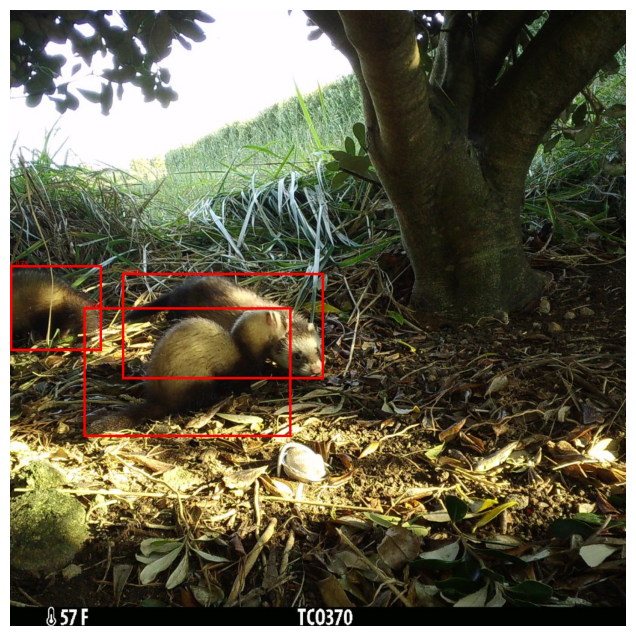

In [45]:
image = Image.open(image_path)
draw = ImageDraw.Draw(image)
w, h = image.size
color_map = { 1: 'red', 2: 'blue', 3: 'yellow' }

for det in detections:
    o_col = color_map.get(int(det["class"]))
    x1, y1 = det["x1"] * w, det["y1"] * h
    x2, y2 = det["x2"] * w, det["y2"] * h
    
    draw.rectangle([x1, y1, x2, y2], outline=o_col, width=4)
    draw.text((x1, y1 - 10), f"{det['class']}: {det['confidence']:.2f}", fill="red")

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

## Get classifications

In [46]:
classifications = {}
for d in detections:
    bbox = [d["y1"], d["x1"], d["y2"], d["x2"]]
    
    response = requests.post(
        "http://localhost:8080/invocations",
        data=json.dumps({
            "bbox": bbox,
            "image": b64_image.decode("utf-8")
        })
    )

    c = response.json()
    highest_conf = max(c.items(), key=lambda x: x[1]) 
    
    print(highest_conf)
    

('mustelid', 0.9999768733978271)
('mustelid', 0.9999998807907104)
('mustelid', 0.9999994039535522)
